In [2]:
!pip install albumentations segmentation-models-pytorch -q

import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.patches as mpatches

# Thiết lập thiết bị
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 512
BATCH_SIZE = 8 # Điều chỉnh tùy theo bộ nhớ GPU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [3]:
# Thay đổi đường dẫn này sau khi bạn Add Dataset vào Input
MODEL_V1_PATH = "/kaggle/input/datasets/duyhuyynh/models/unet_resnet50_deepglobe_512.pth"
MODEL_V3_PATH = "/kaggle/input/datasets/duyhuyynh/models/unet_resnet50_V3_Master.pth"

# Thêm tham số num_classes vào hàm
def get_model(path, num_classes):
    model = smp.Unet(
        encoder_name="resnet50",
        encoder_weights=None,
        in_channels=3,
        classes=num_classes # Cấu hình linh hoạt theo từng model
    ).to(DEVICE)
    
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.eval()
        print(f"✅ Đã nạp thành công: {os.path.basename(path)} (Classes: {num_classes})")
        return model
    else:
        print(f"❌ Không tìm thấy: {path}")
        return None

# Nạp m1 với 7 classes và m3 với 6 classes
m1 = get_model(MODEL_V1_PATH, num_classes=7)
m3 = get_model(MODEL_V3_PATH, num_classes=6)

✅ Đã nạp thành công: unet_resnet50_deepglobe_512.pth (Classes: 7)
✅ Đã nạp thành công: unet_resnet50_V3_Master.pth (Classes: 6)


In [4]:
class SatelliteTestDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        # Logic tìm mask tương ứng (tùy chỉnh theo cấu trúc folder của DeepGlobe/LoveDA)
        mask_name = self.images[idx].replace('_sat.jpg', '_mask.png').replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        return image, mask.long()

# Transform chuẩn cho giai đoạn Test
test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [5]:
def evaluate_model(model, dataloader, num_classes):
    if model is None: return 0.0, 0.0
    
    tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc=f"Đang đánh giá (Classes: {num_classes})"):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            
            # 1. Lấy output thô từ model (dạng số thực float32)
            outputs_raw = model(images)
            
            # 2. FIX LỖI Ở ĐÂY: Dùng argmax để biến xác suất thành ID Class cụ thể (dạng số nguyên int)
            outputs_int = torch.argmax(outputs_raw, dim=1)
            
            # 3. Tính toán với SMP (đưa outputs_int vào thay vì outputs_raw)
            tp, fp, fn, tn = smp.metrics.get_stats(outputs_int, masks, mode='multiclass', num_classes=num_classes)
            
            tp_total += tp.sum()
            fp_total += fp.sum()
            fn_total += fn.sum()
            tn_total += tn.sum()

    # Tính mIoU và F1 dựa trên tổng các batch
    iou = smp.metrics.iou_score(tp_total, fp_total, fn_total, tn_total, reduction="micro")
    f1 = smp.metrics.f1_score(tp_total, fp_total, fn_total, tn_total, reduction="micro")
    
    return iou.item(), f1.item()

In [6]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader

# 1. KHAI BÁO THƯ MỤC GỐC CỦA TẬP VAL LOVEDA
# Dựa theo đường dẫn bạn cung cấp, thư mục gốc là:
VAL_BASE_DIR = "/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/"

class KaggleLoveDA_Val_Dataset(Dataset):
    def __init__(self, val_base_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []
        
        # Quét tự động cả 2 thư mục Urban và Rural
        for env in ['Urban', 'Rural']:
            img_dir = os.path.join(val_base_dir, env, 'images_png')
            mask_dir = os.path.join(val_base_dir, env, 'masks_png')
            
            if os.path.exists(img_dir) and os.path.exists(mask_dir):
                for img_name in os.listdir(img_dir):
                    if img_name.endswith('.png'):
                        self.image_paths.append(os.path.join(img_dir, img_name))
                        self.mask_paths.append(os.path.join(mask_dir, img_name))

        print(f"✅ Đã tìm thấy {len(self.image_paths)} ảnh Validation (Bao gồm cả Urban & Rural)")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Đọc ảnh và mask
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # ---------------------------------------------------------
        # BƯỚC QUAN TRỌNG NHẤT: CHUYỂN ĐỔI NHÃN LOVEDA SANG DEEPGLOBE
        # ---------------------------------------------------------
        loveda_to_dg = {1: 5, 2: 0, 3: 0, 4: 4, 5: 5, 6: 3, 7: 1}
        mask_mapped = np.zeros_like(mask_raw)
        for l_id, dg_id in loveda_to_dg.items():
            mask_mapped[mask_raw == l_id] = dg_id

        # Data Augmentation (Normalize & ToTensor)
        if self.transform:
            augmented = self.transform(image=image, mask=mask_mapped)
            image = augmented['image']
            mask_mapped = augmented['mask']
            
        return image, mask_mapped.long()

# 2. KHỞI TẠO DATALOADER
val_dataset = KaggleLoveDA_Val_Dataset(VAL_BASE_DIR, transform=test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. CHẠY ĐÁNH GIÁ (Sử dụng lại hàm evaluate_model đã sửa num_classes)
print("\n--- Đang đánh giá V1 Baseline trên tập Val LoveDA ---")
iou1, f1_1 = evaluate_model(m1, val_loader, num_classes=7)
print(f"🏆 V1 Baseline -> mIoU: {iou1:.4f} | F1-Score: {f1_1:.4f}")

print("\n--- Đang đánh giá V3 Master trên tập Val LoveDA ---")
iou3, f1_3 = evaluate_model(m3, val_loader, num_classes=6)
print(f"🏆 V3 Master  -> mIoU: {iou3:.4f} | F1-Score: {f1_3:.4f}")

✅ Đã tìm thấy 1669 ảnh Validation (Bao gồm cả Urban & Rural)

--- Đang đánh giá V1 Baseline trên tập Val LoveDA ---


Đang đánh giá (Classes: 7): 100%|██████████| 209/209 [02:43<00:00,  1.27it/s]


🏆 V1 Baseline -> mIoU: 0.1438 | F1-Score: 0.2514

--- Đang đánh giá V3 Master trên tập Val LoveDA ---


Đang đánh giá (Classes: 6): 100%|██████████| 209/209 [02:12<00:00,  1.57it/s]

🏆 V3 Master  -> mIoU: 0.5645 | F1-Score: 0.7217


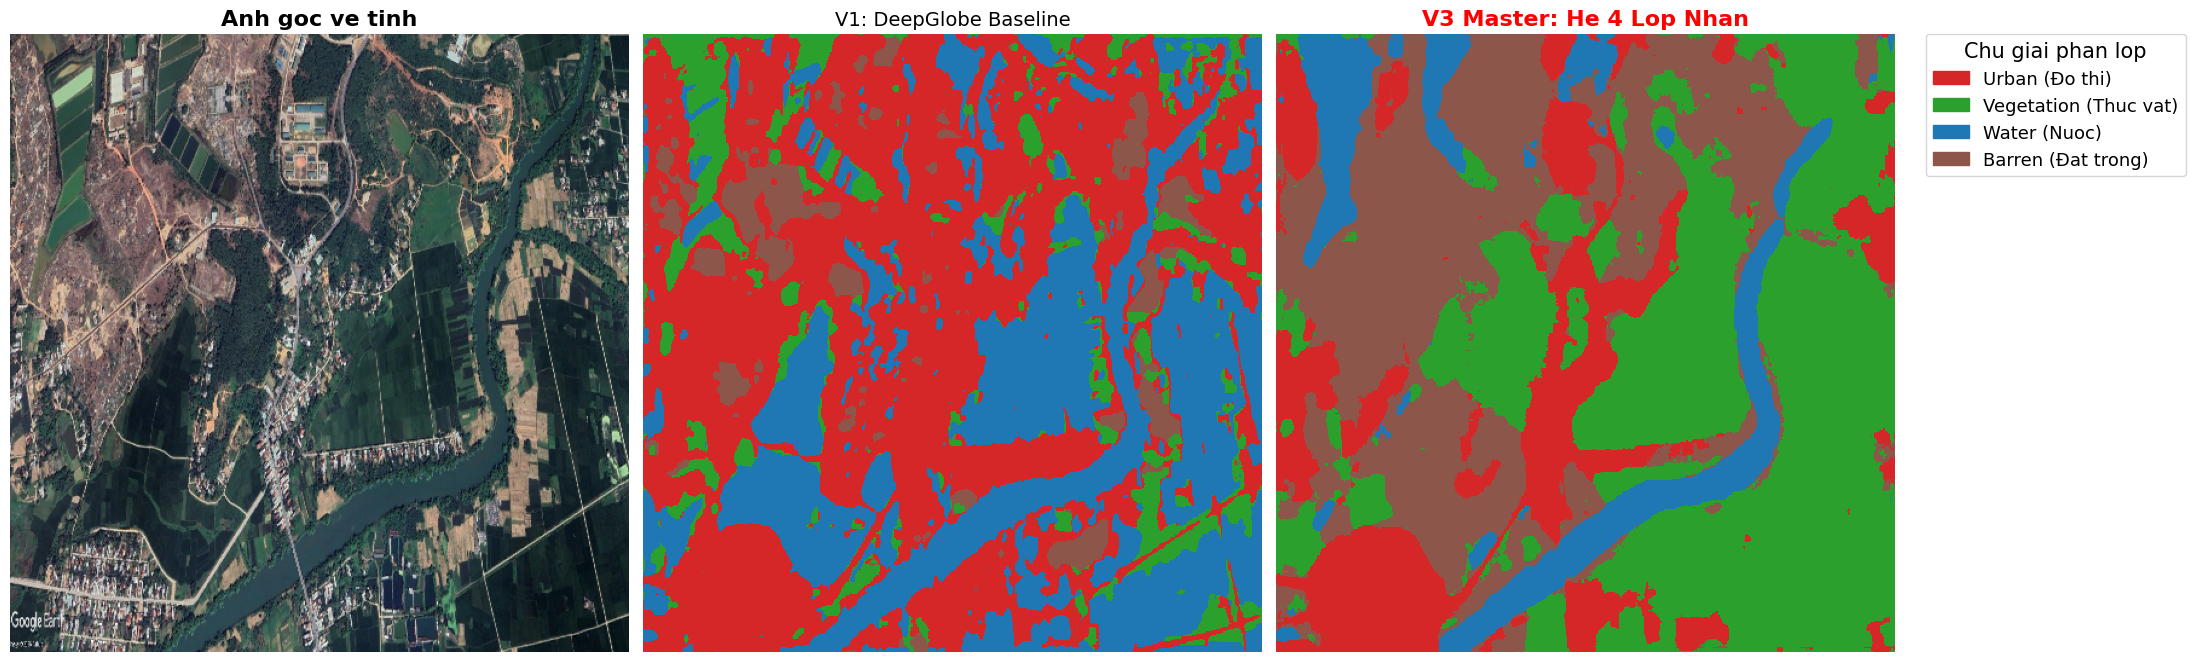

In [10]:
from matplotlib.colors import ListedColormap # Import thư viện tạo màu tự định nghĩa

def test_single_image_with_merged_legend(image_path, model_v1, model_v3, transform, device):
    """
    Hàm nhận diện ảnh với hệ 4 lớp nhãn sáp nhập và màu sắc tùy chỉnh.
    """
    # 1. Đọc và tiền xử lý ảnh
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Không thể đọc ảnh từ đường dẫn: {image_path}")
        return
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_display = cv2.resize(image_rgb, (512, 512))
    input_tensor = transform(image=image_rgb)["image"].unsqueeze(0).to(device)

    # 2. Chạy dự đoán (Inference) ra 6 class gốc
    with torch.no_grad():
        out_v1 = torch.argmax(model_v1(input_tensor), dim=1).cpu().squeeze().numpy()
        out_v3 = torch.argmax(model_v3(input_tensor), dim=1).cpu().squeeze().numpy()

    # 3. ÉP NHÃN (Chuyển 6 class -> 4 class)
    def merge_to_4_classes(mask):
        merged = np.zeros_like(mask) # Khởi tạo toàn bộ là 0 (Urban)
        merged[(mask == 1) | (mask == 3)] = 1 # Nông nghiệp + Rừng -> Vegetation (1)
        merged[mask == 4] = 2                 # Nước -> Water (2)
        merged[(mask == 5) | (mask == 2)] = 3 # Đất trống + Đồng cỏ -> Barren (3)
        return merged

    mask_v1 = merge_to_4_classes(out_v1)
    mask_v3 = merge_to_4_classes(out_v3)

    # 4. KHAI BÁO NHÃN MỚI VÀ MÀU SẮC CHỈ ĐỊNH
    class_names = [
        'Urban (Đo thi)', 
        'Vegetation (Thuc vat)', 
        'Water (Nuoc)', 
        'Barren (Đat trong)'
    ]
    
    # Chỉ định màu: 0: Đỏ, 1: Xanh lá, 2: Xanh biển, 3: Nâu xám
    # Bạn có thể thay đổi mã Hex màu nếu muốn đậm/nhạt hơn
    custom_colors = ['#d62728', '#2ca02c', '#1f77b4', '#8c564b']
    cmap_custom = ListedColormap(custom_colors)

    # 5. Vẽ biểu đồ
    fig, axes = plt.subplots(1, 3, figsize=(22, 7)) 

    # --- Cột 1: Ảnh gốc ---
    axes[0].imshow(image_display)
    axes[0].set_title("Anh goc ve tinh", fontsize=16, fontweight='bold')
    axes[0].axis('off')
    
    # --- Cột 2: V1 ---
    # Chú ý vmin=0, vmax=3 vì ta chỉ còn 4 class (từ 0 đến 3)
    axes[1].imshow(mask_v1, cmap=cmap_custom, vmin=0, vmax=3, interpolation='nearest')
    axes[1].set_title("V1: DeepGlobe Baseline", fontsize=14)
    axes[1].axis('off')
    
    # --- Cột 3: V3 Master ---
    axes[2].imshow(mask_v3, cmap=cmap_custom, vmin=0, vmax=3, interpolation='nearest')
    axes[2].set_title("V3 Master: He 4 Lop Nhan", fontsize=16, color='red', fontweight='bold')
    axes[2].axis('off')
    
    # 6. XỬ LÝ CHÚ THÍCH (LEGEND)
    unique_classes = np.unique(np.concatenate((mask_v1.flatten(), mask_v3.flatten())))
    
    # Gắn đúng màu tự định nghĩa vào các ô màu chú thích
    patches = [mpatches.Patch(color=custom_colors[i], label=class_names[i]) for i in unique_classes if i < len(class_names)]
    
    axes[2].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', 
                   borderaxespad=0., fontsize=13, title="Chu giai phan lop", title_fontsize=15)
    
    plt.tight_layout()
    plt.show()

# THỰC THI
MY_TEST_IMAGE_PATH = "/kaggle/input/datasets/duyhuyynh/test-model-img/test.jpg" 
test_single_image_with_merged_legend(MY_TEST_IMAGE_PATH, m1, m3, test_transform, DEVICE)

In [9]:
def evaluate_v3_with_merged_classes(model, dataloader, device):
    model.eval()
    
    # Định nghĩa 4 hệ nhãn mới cho đồ án
    new_class_names = ['Urban', 'Vegetation', 'Water', 'Barren']
    num_classes = len(new_class_names)
    
    tp_total = torch.zeros(num_classes)
    fp_total = torch.zeros(num_classes)
    fn_total = torch.zeros(num_classes)
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Đang đánh giá hệ 4 lớp nhãn sáp nhập"):
            images, masks = images.to(device), masks.to(device)
            outputs_int = torch.argmax(model(images), dim=1)
            
            # --- TIẾN HÀNH SÁP NHẬP NHÃN ĐỘNG TRÊN TENSOR ---
            # Hệ 6 lớp cũ: 0=Urban, 1=Agri, 2=Range, 3=Forest, 4=Water, 5=Barren
            # Hệ 4 lớp mới: 0=Urban, 1=Vegetation, 2=Water, 3=Barren
            
            # Tạo bản sao để map nhãn mới cho cả Dự đoán và Thực tế
            pred_merged = torch.zeros_like(outputs_int)
            masks_merged = torch.zeros_like(masks)
            
            # Map lớp 0 (Urban) -> 0
            # Map lớp 1 (Agri) và 3 (Forest) -> 1 (Vegetation)
            pred_merged[(outputs_int == 1) | (outputs_int == 3)] = 1
            masks_merged[(masks == 1) | (masks == 3)] = 1
            
            # Map lớp 4 (Water) -> 2
            pred_merged[outputs_int == 4] = 2
            masks_merged[masks == 4] = 2
            
            # Map lớp 5 (Barren) và 2 (Rangeland nếu có) -> 3 (Barren)
            pred_merged[(outputs_int == 5) | (outputs_int == 2)] = 3
            masks_merged[(masks == 5) | (masks == 2)] = 3
            
            # Tính toán chỉ số dựa trên hệ 4 lớp mới
            tp, fp, fn, tn = smp.metrics.get_stats(pred_merged, masks_merged, mode='multiclass', num_classes=num_classes)
            
            tp_total += tp.sum(dim=0).cpu()
            fp_total += fp.sum(dim=0).cpu()
            fn_total += fn.sum(dim=0).cpu()
            
    # Tính toán mIoU mới
    iou_per_class = tp_total / (tp_total + fp_total + fn_total + 1e-7)
    iou_per_class = iou_per_class.numpy() * 100
    macro_mIoU = np.mean(iou_per_class)
    
    print("\n" + "="*50)
    print(f"🏆 mIoU HỆ 4 LỚP (SAU SÁP NHẬP NHÃN): {macro_mIoU:.2f}%")
    print("="*50)
    
    for i, name in enumerate(new_class_names):
        print(f"🔹 {name.ljust(15)}: {iou_per_class[i]:.2f}%")

# Thực thi kiểm tra ngay trên mô hình m3 hiện tại
evaluate_v3_with_merged_classes(m3, val_loader, DEVICE)

Đang đánh giá hệ 4 lớp nhãn sáp nhập: 100%|██████████| 209/209 [02:15<00:00,  1.55it/s]


🏆 mIoU HỆ 4 LỚP (SAU SÁP NHẬP NHÃN): 60.96%
🔹 Urban          : 63.93%
🔹 Vegetation     : 54.74%
🔹 Water          : 68.73%
🔹 Barren         : 56.44%
